In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import random

In [ ]:

W, H = 800, 600
side = 20
min_d = 22  # минимальное расстояние между центрами, чтобы фигуры не накладывались

def is_free(x, y, centers):
    for cx, cy in centers:
        if np.hypot(x - cx, y - cy) < min_d:
            return False
    return True


sq1, tr1 = [], []
while len(sq1) < 100:
    x, y = random.uniform(10, 340), random.uniform(10, H-10)
    if is_free(x, y, sq1): sq1.append((x, y))
while len(tr1) < 100:
    x, y = random.uniform(460, W-10), random.uniform(10, H-10)
    if is_free(x, y, tr1): tr1.append((x, y))


sq2, tr2 = [], []
while len(sq2) < 100:
    x, y = random.uniform(10, 440), random.uniform(10, H-10)
    if is_free(x, y, sq2): sq2.append((x, y))
while len(tr2) < 100:
    x, y = random.uniform(360, W-10), random.uniform(10, H-10)
    if is_free(x, y, tr2): tr2.append((x, y))

sq3, tr3 = [], []
for _ in range(8):
    while True:
        x, y = random.uniform(360, 440), random.uniform(240, 360)
        if is_free(x, y, sq3 + tr3): sq3.append((x, y)); break
for _ in range(4):
    while True:
        x, y = random.uniform(360, 440), random.uniform(240, 360)
        if is_free(x, y, sq3 + tr3): tr3.append((x, y)); break
while len(sq3) < 100:
    x, y = random.uniform(10, 350), random.uniform(10, H-10)
    if is_free(x, y, sq3 + tr3): sq3.append((x, y))
while len(tr3) < 100:
    x, y = random.uniform(450, W-10), random.uniform(10, H-10)
    if is_free(x, y, sq3 + tr3): tr3.append((x, y))

data = [(sq1, tr1), (sq2, tr2), (sq3, tr3)]


Координаты готовы.


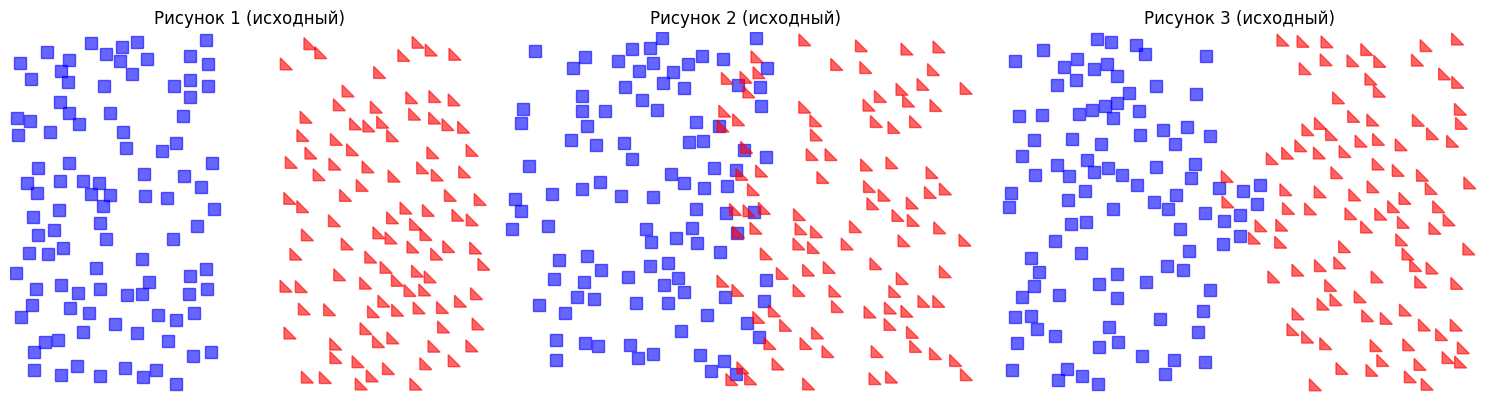

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for i, (ax, (sq, tr)) in enumerate(zip(axes, data)):
    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal')
    ax.axis('off')
    
    for x, y in sq:
        ax.add_patch(patches.Rectangle((x-side/2, y-side/2), side, side, color='blue', alpha=0.6))
    for x, y in tr:
        verts = [(x-side/2, y-side/2), (x+side/2, y-side/2), (x-side/2, y+side/2)]
        ax.add_patch(patches.Polygon(verts, color='red', alpha=0.6))
    ax.set_title(f'Рисунок {i+1} (исходный)')
plt.tight_layout()
plt.show()

In [ ]:

km_results = []
# критерии остановки как в лекции: макс итераций + точность
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.5)

for i, (sq, tr) in enumerate(data):
    X = np.array(sq + tr, dtype=np.float32)
    _, labels, _ = cv2.kmeans(X, 2, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.ravel()
    km_results.append((X, labels))
    
    c0 = np.sum(labels == 0)
    c1 = np.sum(labels == 1)

Рисунок 1: k-means разбил на кластеры 100 и 100
Рисунок 2: k-means разбил на кластеры 90 и 110
Рисунок 3: k-means разбил на кластеры 103 и 97


In [ ]:

circles_data = []
predictions = []
k = 3 

for i, (sq, tr) in enumerate(data):
    zones = [(10, 340, 10, H-10), (460, W-10, 10, H-10), (360, 440, 240, 360)]
    circ_pts = []
    all_centers = np.array(sq + tr)
    
    for zone in zones:
        placed = 0
        while placed < 3:
            x = random.uniform(zone[0], zone[1])
            y = random.uniform(zone[2], zone[3])
            if np.all(np.hypot(x - all_centers[:,0], y - all_centers[:,1]) > side):
                circ_pts.append((x, y))
                placed += 1
    circles_data.append(circ_pts)
    
    X_train = km_results[i][0]
    y_train = km_results[i][1].reshape(-1, 1).astype(np.float32)
    
    knn = cv2.ml.KNearest_create()
    knn.train(X_train, cv2.ml.ROW_SAMPLE, y_train)
    
    X_circles = np.array(circ_pts, dtype=np.float32)
    _, res, neighbours, dist = knn.findNearest(X_circles, k)
    preds = res.ravel()
    predictions.append(preds)
    print(f"Рисунок {i+1} круги: предсказанные классы {preds.astype(int)}")

Рисунок 1 круги: предсказанные классы [0 0 0 1 1 1 1 1 1]
Рисунок 2 круги: предсказанные классы [1 1 1 0 0 1 0 1 1]
Рисунок 3 круги: предсказанные классы [1 1 1 0 0 0 0 0 0]


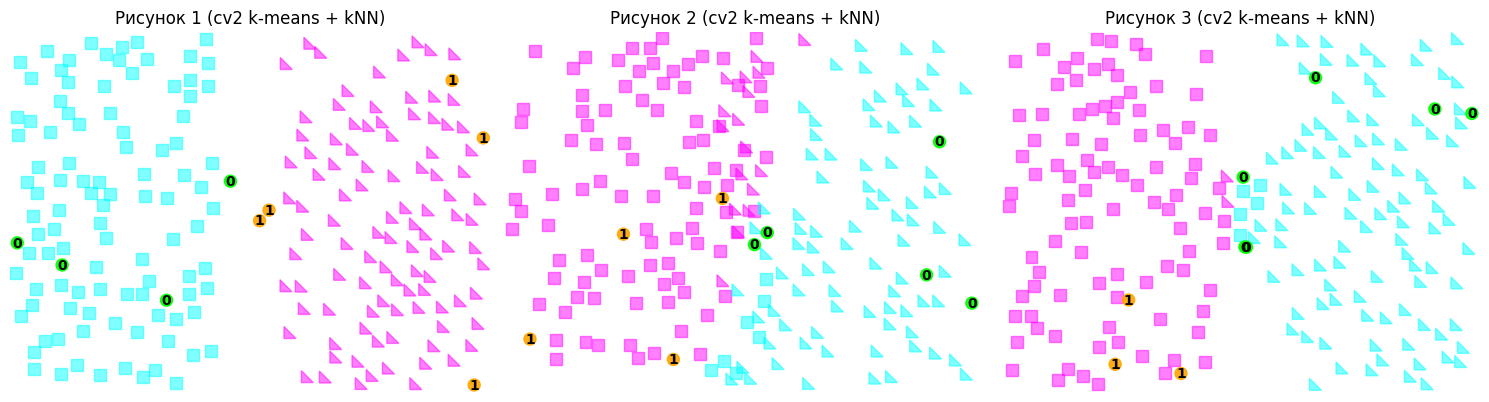

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
colors_knn = {0: 'lime', 1: 'orange'}
colors_km = {0: 'cyan', 1: 'magenta'}

for i, (ax, (sq, tr), (X, labels), circs, preds) in enumerate(zip(axes, data, km_results, circles_data, predictions)):
    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # раскрашиваем фигуры по меткам k-means
    sq_labels = labels[:100]
    tr_labels = labels[100:]
    for (x, y), lab in zip(sq, sq_labels):
        ax.add_patch(patches.Rectangle((x-side/2, y-side/2), side, side, color=colors_km[lab], alpha=0.5))
    for (x, y), lab in zip(tr, tr_labels):
        verts = [(x-side/2, y-side/2), (x+side/2, y-side/2), (x-side/2, y+side/2)]
        ax.add_patch(patches.Polygon(verts, color=colors_km[lab], alpha=0.5))
        
    # рисуем круги и подписываем класс от kNN
    for (cx, cy), p in zip(circs, preds):
        ax.add_patch(patches.Circle((cx, cy), side/2, color=colors_knn[p], alpha=0.9))
        ax.text(cx, cy, str(int(p)), ha='center', va='center', fontsize=10, fontweight='bold', color='black')
        
    ax.set_title(f'Рисунок {i+1} (cv2 k-means + kNN)')
plt.tight_layout()
plt.show()